In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:
# Use interactive widget backend if ipympl is available; otherwise fallback to inline
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.')


ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.


In [4]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [5]:
""" val = Validation()
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
processed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation") """

' val = Validation()\nval.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")\nprocessed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation") '

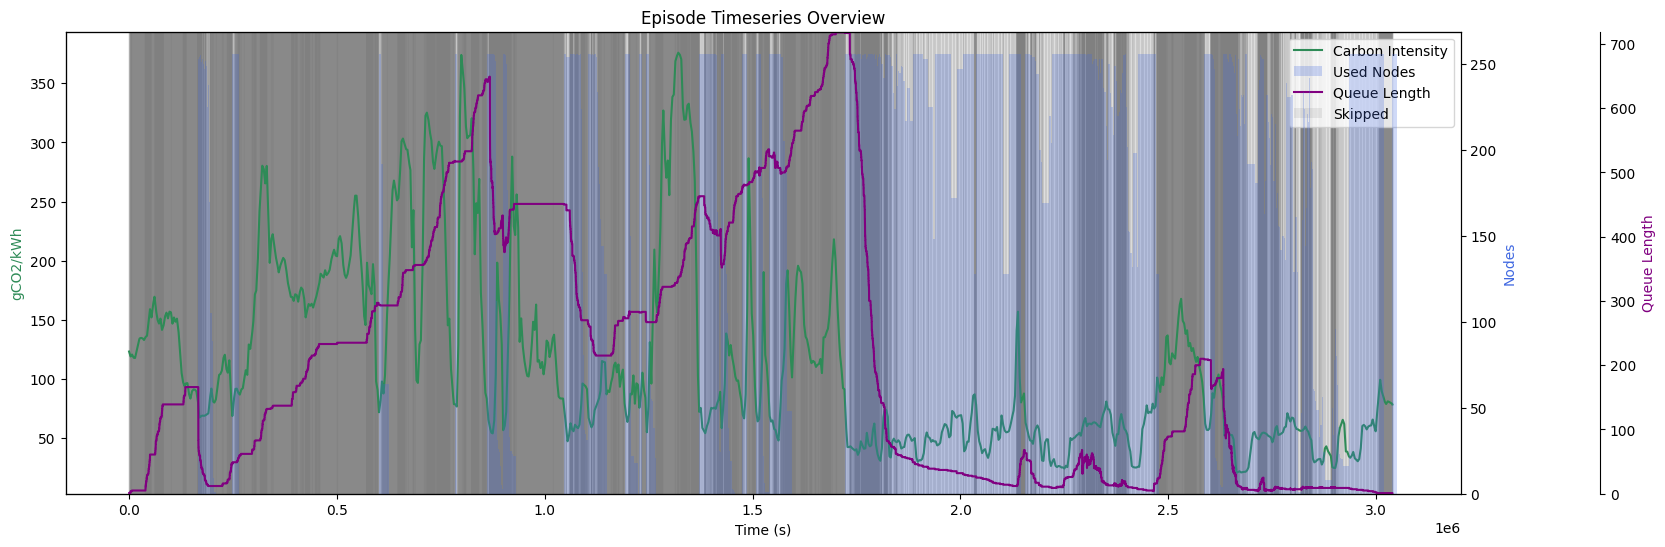

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.render_timeseries_plot(raw_stats['50-percentile Baseline']['action_traces'])

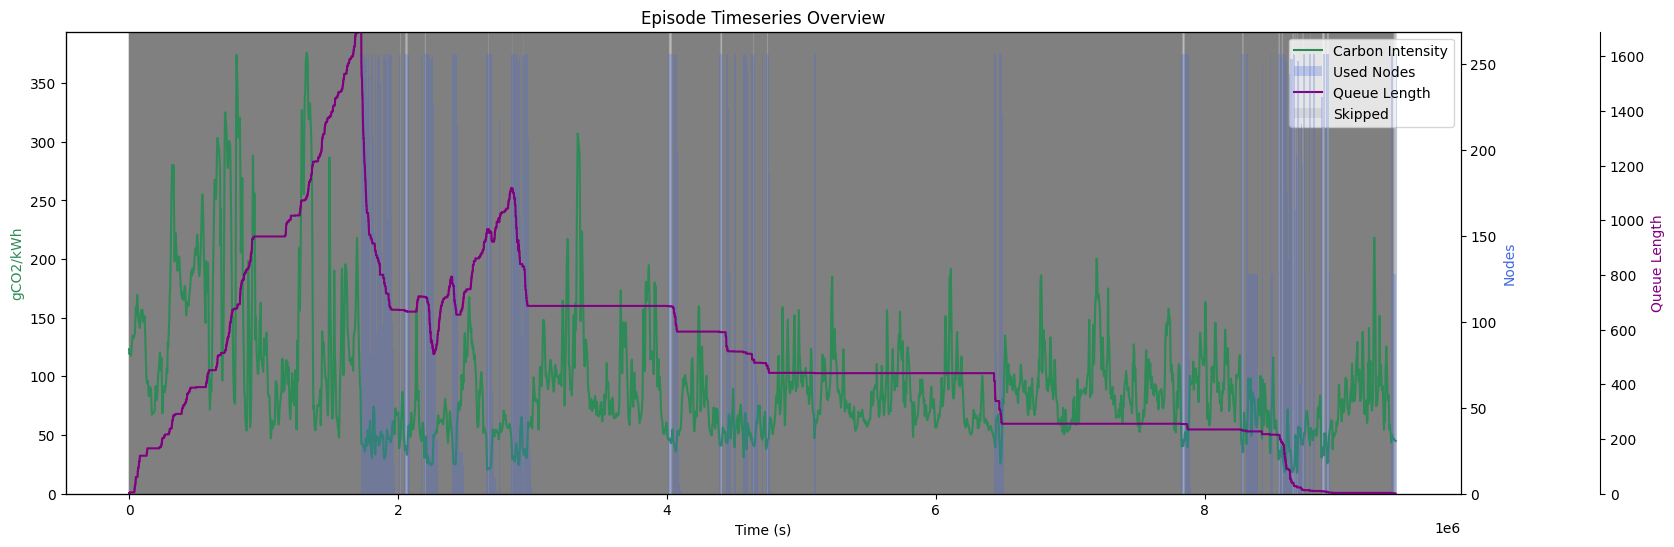

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['25-percentile Baseline']['action_traces'])

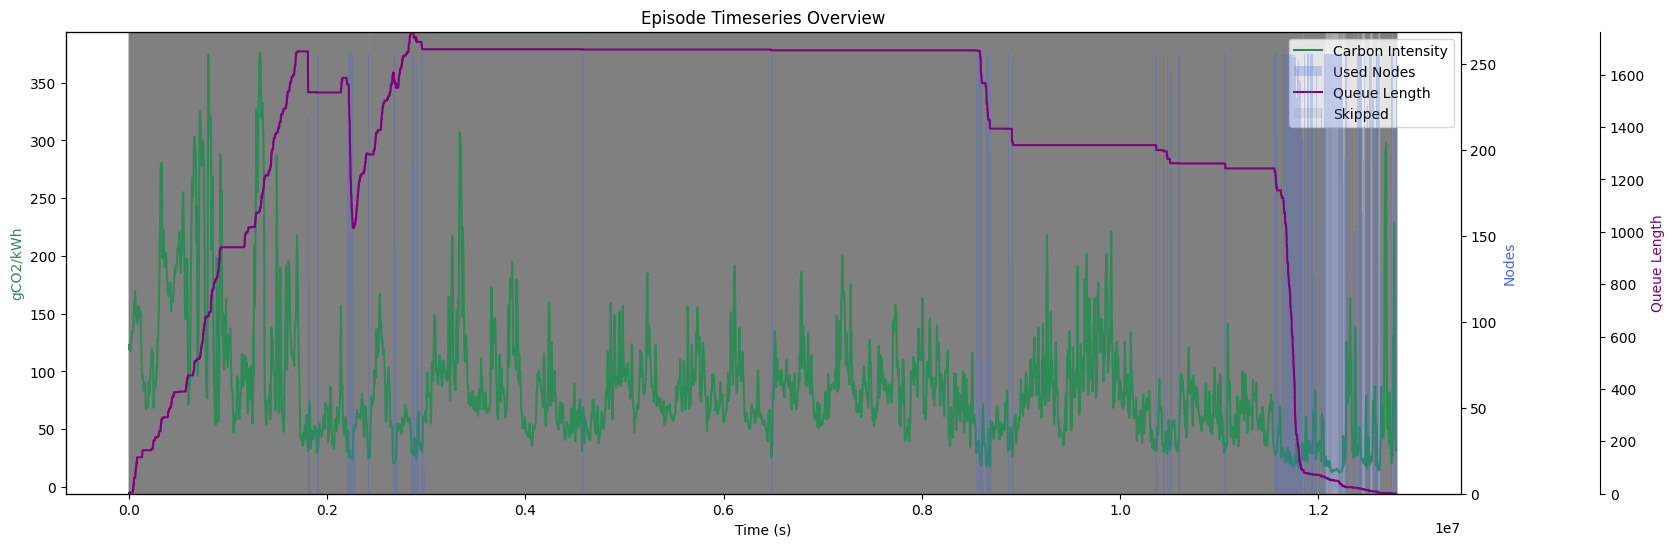

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['10-percentile Baseline']['action_traces'])

In [ ]:
processed_stats

{'FCFS Baseline': {'Avg Wait': np.float64(4552.721755725191),
  'Max Wait': np.float64(4552.721755725191),
  'Avg Response': np.float64(8991.09351145038),
  'Avg Slowdown': np.float64(127.53263829568381),
  'Carbon Emissions': np.float64(9349788.624349324),
  'Weighted Carbon Emissions': np.float64(-9349788.624349324),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10603,
   'Schedule Action Percentage': 24.70998773931906,
   'Fixed Delay Percentage': 24.38932377628973,
   'Wait Delay Percentage': 50.90068848439121,
   'Fixed Delays': {'300s': 2586},
   'Wait for Jobs': {'1 jobs': 5397}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(6431648.060305344),
  'Max Wait': np.float64(6431648.060305344),
  'Avg Response': np.float64(6436086.432061069),
  'Avg Slowdown': np.float64(289532.42415359936),
  'Carbon Emissions': np.float64(6740089.32170967),
  'Weighted Carbon Emissions': np.float64(-6740089.32170967),
  'System Utilization': n

In [11]:
val = Validation()
val.load_dir("results/golden-wave-113")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=None, mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980


In [9]:
processed_stats

{'seed_1_1000000_steps.zip': {'Avg Wait': np.float64(45867.64122137405),
  'Max Wait': np.float64(45867.64122137405),
  'Avg Response': np.float64(50306.012977099235),
  'Avg Slowdown': np.float64(2122.2436184523613),
  'Carbon Emissions': np.float64(9234499.57455122),
  'Weighted Carbon Emissions': np.float64(-9234499.57455122),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10575,
   'Schedule Action Percentage': 24.775413711583923,
   'Fixed Delay Percentage': 72.60520094562648,
   'Wait Delay Percentage': 2.6193853427895983,
   'Fixed Delays': {'1800s': 19,
    '300s': 1891,
    '1200s': 4481,
    '2400s': 375,
    '600s': 911,
    '3600s': 1},
   'Wait for Jobs': {'1 jobs': 246, '2 jobs': 4, '3 jobs': 27}}},
 'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(29268.885877862594),
  'Max Wait': np.float64(29268.885877862594),
  'Avg Response': np.float64(33707.25763358779),
  'Avg Slowdown': np.float64(1281.384322510198),
  'Carbon 

In [ ]:
{'seed_1_1000000_steps.zip': {'Avg Wait': np.float64(38872.987404580155),
  'Max Wait': np.float64(38872.987404580155),
  'Avg Response': np.float64(43311.35916030534),
  'Avg Slowdown': np.float64(1489.8845163117558),
  'Carbon Emissions': np.float64(9150966.558763998),
  'Weighted Carbon Emissions': np.float64(-9150966.558763998),
  'System Utilization': np.float64(0.4422815509172179),
  'Action Analysis': {'Total Actions': 8939,
   'Schedule Action Percentage': 29.309766193086475,
   'Fixed Delay Percentage': 40.709251594138046,
   'Wait Delay Percentage': 29.980982212775476,
   'Fixed Delays': {'1800s': 1002,
    '3600s': 10,
    '1200s': 2147,
    '300s': 119,
    '3000s': 357,
    '600s': 2,
    '2400s': 2},
   'Wait for Jobs': {'3 jobs': 2647, '1 jobs': 27, '2 jobs': 6}}},
 'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(63645.93282442748),
  'Max Wait': np.float64(63645.93282442748),
  'Avg Response': np.float64(68084.30458015268),
  'Avg Slowdown': np.float64(2765.9974486387514),
  'Carbon Emissions': np.float64(9035064.591793105),
  'Weighted Carbon Emissions': np.float64(-9035064.591793105),
  'System Utilization': np.float64(0.44737427430532156),
  'Action Analysis': {'Total Actions': 9789,
   'Schedule Action Percentage': 26.76473592808254,
   'Fixed Delay Percentage': 51.28205128205128,
   'Wait Delay Percentage': 21.953212789866175,
   'Fixed Delays': {'3000s': 83,
    '1800s': 49,
    '3600s': 816,
    '2400s': 90,
    '300s': 2257,
    '600s': 402,
    '1200s': 1323},
   'Wait for Jobs': {'2 jobs': 182, '1 jobs': 1595, '3 jobs': 372}}},
 'seed_1_2000000_steps.zip': {'Avg Wait': np.float64(904152.520610687),
  'Max Wait': np.float64(904152.520610687),
  'Avg Response': np.float64(908590.8923664122),
  'Avg Slowdown': np.float64(40812.89514256688),
  'Carbon Emissions': np.float64(10103012.032682786),
  'Weighted Carbon Emissions': np.float64(-10103012.032682786),
  'System Utilization': np.float64(0.3339073236219857),
  'Action Analysis': {'Total Actions': 11589,
   'Schedule Action Percentage': 22.607645180774874,
   'Fixed Delay Percentage': 74.62248684096988,
   'Wait Delay Percentage': 2.769867978255242,
   'Fixed Delays': {'2400s': 93,
    '1800s': 86,
    '3000s': 6,
    '300s': 42,
    '600s': 5190,
    '1200s': 3228,
    '3600s': 3},
   'Wait for Jobs': {'3 jobs': 268, '2 jobs': 53}}},
 'seed_1_2500000_steps.zip': {'Avg Wait': np.float64(117206.09847328244),
  'Max Wait': np.float64(117206.09847328244),
  'Avg Response': np.float64(121644.47022900764),
  'Avg Slowdown': np.float64(4927.1117421583385),
  'Carbon Emissions': np.float64(9160477.174398202),
  'Weighted Carbon Emissions': np.float64(-9160477.174398202),
  'System Utilization': np.float64(0.44349924244309563),
  'Action Analysis': {'Total Actions': 9793,
   'Schedule Action Percentage': 26.753803737363423,
   'Fixed Delay Percentage': 51.39385275196568,
   'Wait Delay Percentage': 21.852343510670888,
   'Fixed Delays': {'3000s': 13, '300s': 62, '600s': 1556, '1200s': 3402},
   'Wait for Jobs': {'1 jobs': 4, '2 jobs': 37, '3 jobs': 2099}}},
 'seed_1_3000000_steps.zip': {'Avg Wait': np.float64(43254.7213740458),
  'Max Wait': np.float64(43254.7213740458),
  'Avg Response': np.float64(47693.09312977099),
  'Avg Slowdown': np.float64(1760.7702863722236),
  'Carbon Emissions': np.float64(9498929.547369653),
  'Weighted Carbon Emissions': np.float64(-9498929.547369653),
  'System Utilization': np.float64(0.44742880916396194),
  'Action Analysis': {'Total Actions': 11274,
   'Schedule Action Percentage': 23.239311690615576,
   'Fixed Delay Percentage': 73.62072024126309,
   'Wait Delay Percentage': 3.139968068121341,
   'Fixed Delays': {'1200s': 1071,
    '300s': 309,
    '3000s': 11,
    '600s': 6896,
    '3600s': 8,
    '2400s': 4,
    '1800s': 1},
   'Wait for Jobs': {'2 jobs': 196, '3 jobs': 158}}},
 'seed_1_500000_steps.zip': {'Avg Wait': np.float64(16607.18969465649),
  'Max Wait': np.float64(16607.18969465649),
  'Avg Response': np.float64(21045.56145038168),
  'Avg Slowdown': np.float64(453.7653807179799),
  'Carbon Emissions': np.float64(9329014.728126928),
  'Weighted Carbon Emissions': np.float64(-9329014.728126928),
  'System Utilization': np.float64(0.45039880845887453),
  'Action Analysis': {'Total Actions': 9548,
   'Schedule Action Percentage': 27.440301633850023,
   'Fixed Delay Percentage': 70.70590699622957,
   'Wait Delay Percentage': 1.853791369920402,
   'Fixed Delays': {'600s': 2249,
    '300s': 177,
    '1200s': 1537,
    '3000s': 2615,
    '1800s': 162,
    '2400s': 5,
    '3600s': 6},
   'Wait for Jobs': {'1 jobs': 166, '3 jobs': 11}}}}

In [ ]:
val.render_timeseries_plot(raw_stats['seed_1_1500000_steps']['action_traces'])

KeyError: 'seed_1_1500000_steps'

In [ ]:
val = Validation()
val.load_dir("results/results_smart_flower")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=None, mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980


In [ ]:
processed_stats

{'seed_1_1000000_steps.zip': {'Avg Wait': np.float64(45867.64122137405),
  'Max Wait': np.float64(45867.64122137405),
  'Avg Response': np.float64(50306.012977099235),
  'Avg Slowdown': np.float64(2122.2436184523613),
  'Carbon Emissions': np.float64(9234499.57455122),
  'Weighted Carbon Emissions': np.float64(-9234499.57455122),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10575,
   'Schedule Action Percentage': 24.775413711583923,
   'Fixed Delay Percentage': 72.60520094562648,
   'Wait Delay Percentage': 2.6193853427895983,
   'Fixed Delays': {'1800s': 19,
    '300s': 1891,
    '1200s': 4481,
    '2400s': 375,
    '600s': 911,
    '3600s': 1},
   'Wait for Jobs': {'1 jobs': 246, '2 jobs': 4, '3 jobs': 27}}},
 'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(29268.885877862594),
  'Max Wait': np.float64(29268.885877862594),
  'Avg Response': np.float64(33707.25763358779),
  'Avg Slowdown': np.float64(1281.384322510198),
  'Carbon 